In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


2


In [ ]:
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )


print("MGSD Test set balance:\n", sample_mgsd["label"].value_counts())
print("MGSD Few-shot examples balance:\n", sample_examples_mgsd["label"].value_counts())

print("MentalManip Test set balance:\n", sample_mentalmanip["manipulative"].value_counts())
print("MentalManip Few-shot examples balance:\n", sample_examples_mentalmanip["manipulative"].value_counts())

MGSD Test set balance:
 label
anti-stereotype    200
stereotype         200
unrelated          100
Name: count, dtype: int64
MGSD Few-shot examples balance:
 label
stereotype         5
anti-stereotype    5
unrelated          5
Name: count, dtype: int64
MentalManip Test set balance:
 manipulative
0    250
1    250
Name: count, dtype: int64
MentalManip Few-shot examples balance:
 manipulative
1    5
0    5
Name: count, dtype: int64


In [ ]:
from dotenv import load_dotenv
import openai
import os, torch, numpy as np
from utils import call_llm
import json
from sklearn.pipeline import make_pipeline

load_dotenv()

ENV_VARS = {
    "API_KEY_OPENAI": "OpenAI",
}

for var, name in ENV_VARS.items():
    if not os.getenv(var):
        raise ValueError(f"Missing {name} API key: `{var}` must be set in the environment.")


client = openai.OpenAI(api_key= os.getenv("API_KEY_AZURE_OPENAI"))
#client = openai.AzureOpenAI(api_version="2024-12-01-preview", azure_endpoint=os.getenv("ENDPOINT_AZURE_OPENAI"), api_key=os.getenv("API_KEY_AZURE_OPENAI"),)
model = "gpt-4.1-mini"
model_filename = "openai_4.1_mini"

## Chain of Thoughts

In [ ]:
import pandas as pd
import os, json
from stereotype_def import stereotype_definition, stereotype_definition_short
from mentalmanip_def import mental_manipulation_def1, mental_manipulation_def1_short
from case_studies import stereotypes, manipulation
from chain_of_thought import ChainOfThoughts
from sklearn.metrics import classification_report, confusion_matrix

# Configuration
case_name = "stereotype"  # "stereotype" "manipulation"
num_reasoning_steps = 3
max_tokens = 600


def get_sample_data(case_name, data, case):
    """Extract one sample per label for testing."""
    if case_name.lower() == "manipulation":
        samples = []
        for label in [0, 1]:
            sample = data[data[case["label_col"]] == label].iloc[0]
            samples.append(sample)
        return pd.DataFrame(samples).reset_index(drop=True)
    
    elif case_name.lower() == "stereotype":
        samples = []
        for label in ["stereotype", "anti-stereotype", "unrelated"]:
            sample = data[data[case["label_col"]] == label].iloc[0]
            samples.append(sample)
        return pd.DataFrame(samples).reset_index(drop=True)


if case_name.lower() == "manipulation":
    case = manipulation
    task_definition = mental_manipulation_def1_short
    data = sample_mentalmanip  
    
elif case_name.lower() == "stereotype":
    case = stereotypes
    task_definition = stereotype_definition_short
    data = sample_mgsd  
    
else:
    raise ValueError(f"Unknown case name: {case_name}")


sample_data = get_sample_data(case_name, data, case)
print(f"Testing with {len(sample_data)} samples:")
print(sample_data[case["label_col"]].value_counts())


cot_classifier = ChainOfThoughts(
    case=case,
    client=client,  
    model=model,   
    max_tokens=max_tokens,
    task_definition=task_definition,
    num_reasoning_steps=num_reasoning_steps
)

print(f"\n=== Running CoT with {max_tokens} tokens and {num_reasoning_steps} reasoning steps ===")


results = []
detailed_outputs = []

for idx, row in sample_data.iterrows():
    text = row[case["input_col"]]
    true_label = row[case["label_col"]]
    
    if isinstance(true_label, str):
        true_label = true_label.strip()
    
    print(f"\n{'='*80}")
    print(f"SAMPLE {idx + 1} - True Label: {true_label}")
    print(f"Input: {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"{'='*80}")
    

    cot_result, stat = cot_classifier.classify_with_reasoning(text)
    predicted_label = cot_result.final_label
    

    mapped_label = case["label_map"].get(
        predicted_label.strip(), 
        list(case["label_map"].values())[-1]
    )
    

    cot_classifier.print_reasoning(cot_result)
    

    result = {
        "sample_id": idx,
        "text": text,
        "true_label": true_label,
        "pred_label": mapped_label,
        "raw_pred_label": predicted_label,
        "correct": true_label == mapped_label,
        "confidence": cot_result.confidence,
        "num_reasoning_steps": len(cot_result.reasoning_steps),
    }
    
    results.append(result)
    

    detailed_output = {
        "sample_id": idx,
        "input_text": text,
        "true_label": true_label,
        "predicted_label": mapped_label,
        "reasoning_steps": [
            {
                "step": step.step_number,
                "content": step.content
            }
            for step in cot_result.reasoning_steps
        ],
        "final_reasoning": cot_result.final_reasoning,
        "confidence": cot_result.confidence
    }
    detailed_outputs.append(detailed_output)
    
    print(f"\nResult: {true_label} -> {mapped_label} ({'✓' if true_label == mapped_label else '✗'})")
    if cot_result.confidence > 0:
        print(f"Confidence: {cot_result.confidence:.2f}")


print(f"\n{'='*80}")
print("SUMMARY RESULTS")
print(f"{'='*80}")

df_results = pd.DataFrame(results)
accuracy = df_results["correct"].mean()
print(f"Accuracy: {accuracy:.2%} ({df_results['correct'].sum()}/{len(df_results)})")

if case_name == "manipulation":
    y_true = df_results["true_label"].astype(int)
    y_pred = df_results["pred_label"].astype(int)
elif case_name == "stereotype":
    y_true = df_results["true_label"]
    y_pred = df_results["pred_label"].astype(str).str.strip().str.lower()

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred))

print("\n=== Confusion Matrix ===")
labels = sorted(set(y_true) | set(y_pred))
conf_matrix = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(conf_matrix, index=labels, columns=labels))


metrics = cot_classifier.get_metrics()
print(f"\n=== Performance Metrics ===")
print(f"Total tokens used: {metrics['total_tokens']}")
print(f"Average tokens per call: {metrics['avg_tokens_per_call']:.1f}")
print(f"Total latency: {metrics['total_latency']:.2f}s")
print(f"Average latency per call: {metrics['avg_latency_per_call']:.2f}s")


output_dir = "results/cot/sample_test"
os.makedirs(output_dir, exist_ok=True)


results_file = f"{output_dir}/sample_results_{case_name.lower()}_cot.csv"
df_results.to_csv(results_file, index=False)
print(f"\n=== Saved results to {results_file} ===")


reasoning_file = f"{output_dir}/sample_reasoning_{case_name.lower()}_cot.json"
with open(reasoning_file, 'w', encoding='utf-8') as f:
    json.dump(detailed_outputs, f, indent=2, ensure_ascii=False)
print(f"=== Saved detailed reasoning to {reasoning_file} ===")

print(f"\n{'='*80}")
print("SAMPLE TEST COMPLETE")
print(f"{'='*80}")


print(f"\n{'='*80}")
print("COMPLETE REASONING CHAINS")
print(f"{'='*80}")

for i, output in enumerate(detailed_outputs):
    print(f"\n--- SAMPLE {i+1}: {output['true_label']} -> {output['predicted_label']} ---")
    
    for step in output['reasoning_steps']:
        print(f"\nStep {step['step']}:")
        print(step['content'])
    
    print(f"\nFinal Reasoning: {output['final_reasoning']}")
    print(f"Final Decision: {output['predicted_label']}")
    if output['confidence'] > 0:
        print(f"Confidence: {output['confidence']:.2f}")
    print("-" * 60)

Testing with 3 samples:
label
stereotype         1
anti-stereotype    1
unrelated          1
Name: count, dtype: int64

=== Running CoT with 600 tokens and 3 reasoning steps ===

SAMPLE 1 - True Label: stereotype
Input: The maid does a good job cleaning, vacuuming and making beds. She is an illegal immigrant from Mexico and speaks little English.

=== Chain of Thoughts Analysis for stereotype ===
------------------------------------------------------------

Step 1:
**
- The text describes a maid and her work duties (cleaning, vacuuming, making beds).
- It specifies that she is an illegal immigrant from Mexico and that she speaks little English.
- Key elements include her job (maid), her immigration status, her nationality, and her language abilities.

**

Step 2:
**
- The mention of the maid's job introduces an occupational stereotype, which may imply assumptions about the types of work immigrants are likely to do.
- Identifying her as an illegal immigrant reinforces a stereotype regar

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

# Up-to-date

In [14]:
from tqdm import tqdm
import os, json
from chain_of_thought import ChainOfThoughts
from stereotype_def import stereotype_definition, stereotype_definition_short
from mentalmanip_def import mental_manipulation_def1, mental_manipulation_def1_short
from case_studies import stereotypes, manipulation
from sklearn.metrics import classification_report, confusion_matrix

case_name = "manipulation"  # "stereotype" "manipulation"

# CoT specific parameters
reasoning_steps = [2, 4] #[2, 3, 4] 
regime = ["medium"] #["low", "medium", "high"]
regime_tokens = {"low": 400, "medium": 600, "high": 800}  


os.makedirs("results/cot", exist_ok=True)
for reg in regime:
    os.makedirs(f"results/cot/{reg}", exist_ok=True)

try:
    for token_regime in regime:
        for num_steps in reasoning_steps:
            print(f"\n=== Running CoT with {token_regime} tokens and {num_steps} reasoning steps ===")
            
            if case_name.lower() == "manipulation":
                case = manipulation
                task_definition = mental_manipulation_def1_short
                data = sample_mentalmanip
                examples_df = sample_examples_mentalmanip
            
            elif case_name.lower() == "stereotype":
                case = stereotypes
                task_definition = stereotype_definition_short
                data = sample_mgsd
                examples_df = sample_examples_mgsd
            
            else:
                raise ValueError(f"Unknown case name: {case_name}")
            

            cot_classifier = ChainOfThoughts(
                case=case,
                client=client,
                model=model,
                max_tokens=regime_tokens[token_regime],
                task_definition=task_definition,
                num_reasoning_steps=num_steps
            )
            
            rows = []
            detailed_reasoning = []
            
            for idx, row in tqdm(data.iterrows(), total=len(data), 
                               desc=f"Processing {token_regime}-{num_steps}steps"):
                text = row[case["input_col"]]
                true_label = row[case["label_col"]]
                
                if isinstance(true_label, str):
                    true_label = true_label.strip()
                
                cot_result = cot_classifier.classify_with_reasoning(text)
                predicted_label = cot_result.final_label
                
                mapped_label = case["label_map"].get(
                    predicted_label.strip(), 
                    list(case["label_map"].values())[-1]
                )
                

                results = {
                    "sample_id": idx,
                    "text": text,
                    "true_label": true_label,
                    "pred_label": mapped_label,
                    "raw_pred_label": predicted_label,
                    "max_tokens": cot_classifier.max_tokens,
                    "tokens_used": cot_classifier.total_tokens,
                    "prompt_tokens": cot_classifier.total_prompt_tokens,
                    "completion_tokens": cot_classifier.total_completion_tokens,
                    "latency": cot_classifier.total_latency,
                    "num_reasoning_steps": len(cot_result.reasoning_steps),
                    "confidence": cot_result.confidence,
                }
                
                rows.append(results)
                
                reasoning_detail = {
                    "sample_id": idx,
                    "reasoning_steps": [
                        {
                            "step": step.step_number,
                            "content": step.content
                        }
                        for step in cot_result.reasoning_steps
                    ],
                    "final_reasoning": cot_result.final_reasoning,
                    "final_label": cot_result.final_label,
                    "confidence": cot_result.confidence
                }
                detailed_reasoning.append(reasoning_detail)
            
            output_file = f"results/cot/{token_regime}/results_{case_name.lower()}_cot_{num_steps}steps.csv"
            reasoning_file = f"results/cot/{token_regime}/reasoning_{case_name.lower()}_cot_{num_steps}steps.json"
            
            df_out = pd.DataFrame(rows)
            df_out.to_csv(output_file, index=False)
            print(f"=== Saved {len(df_out)} rows to {output_file}")
            
            with open(reasoning_file, 'w', encoding='utf-8') as f:
                json.dump(detailed_reasoning, f, indent=2, ensure_ascii=False)
            print(f"=== Saved detailed reasoning to {reasoning_file}")
            
            if case_name == "manipulation":
                y_true = df_out["true_label"].astype(int)
                y_pred = df_out["pred_label"].astype(int)
            
            elif case_name == "stereotype":
                y_true = df_out["true_label"]
                y_pred = df_out["pred_label"].astype(str).str.strip().str.lower()
            
            print("=== Classification Report ===\n")
            print(classification_report(y_true, y_pred))
            
            print("\n=== Confusion Matrix ===\n")
            labels = sorted(set(y_true) | set(y_pred))
            conf_matrix = confusion_matrix(y_true, y_pred)
            print(pd.DataFrame(conf_matrix, index=labels, columns=labels))
            
            accuracy = (y_true == y_pred).mean()
            print(f"\n=== Accuracy: {accuracy:.2%} ===")
            
            metrics = cot_classifier.get_metrics()
            print(f"\n=== CoT Performance Metrics ===")
            print(f"Average tokens per call: {metrics['avg_tokens_per_call']:.1f}")
            print(f"Average latency per call: {metrics['avg_latency_per_call']:.2f}s")
            print(f"Total calls: {metrics['total_calls']}")
            
            print(f"\n=== Sample Reasoning Chains ===")
            for i, reasoning in enumerate(detailed_reasoning[:3]):
                print(f"\nSample {reasoning['sample_id']}:")
                print(f"Final Label: {reasoning['final_label']}")
                if reasoning['confidence'] > 0:
                    print(f"Confidence: {reasoning['confidence']:.2f}")
                print("Reasoning Steps:")
                for step in reasoning['reasoning_steps']:
                    print(f"  Step {step['step']}: {step['content'][:100]}...")
                print(f"Final Reasoning: {reasoning['final_reasoning'][:150]}...")
                print("-" * 50)

except Exception as e:
    print(f"Error with regime={token_regime}, steps={num_steps}: {e}")
    import traceback
    traceback.print_exc()

print("\n=== Chain-of-Thoughts Evaluation Complete ===")


=== Running CoT with medium tokens and 2 reasoning steps ===


Processing medium-2steps: 100%|██████████| 100/100 [14:13<00:00,  8.54s/it]


=== Saved 100 rows to results/cot/medium/results_manipulation_cot_2steps.csv
=== Saved detailed reasoning to results/cot/medium/reasoning_manipulation_cot_2steps.json
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.59      0.47      0.53        40
           1       0.69      0.78      0.73        60

    accuracy                           0.66       100
   macro avg       0.64      0.63      0.63       100
weighted avg       0.65      0.66      0.65       100


=== Confusion Matrix ===

    0   1
0  19  21
1  13  47

=== Accuracy: 66.00% ===

=== CoT Performance Metrics ===
Average tokens per call: 983.8
Average latency per call: 8.54s
Total calls: 100

=== Sample Reasoning Chains ===

Sample 0:
Final Label: Yes
Reasoning Steps:
  Step 1: - In the provided text, Person1 and Person2 are having a dialogue that contains a narrative about so...
  Step 2: - The relevant feature for detecting manipulation here would be the assertion

Processing medium-4steps: 100%|██████████| 100/100 [18:11<00:00, 10.91s/it]

=== Saved 100 rows to results/cot/medium/results_manipulation_cot_4steps.csv
=== Saved detailed reasoning to results/cot/medium/reasoning_manipulation_cot_4steps.json
=== Classification Report ===

              precision    recall  f1-score   support

           0       0.67      0.50      0.57        40
           1       0.71      0.83      0.77        60

    accuracy                           0.70       100
   macro avg       0.69      0.67      0.67       100
weighted avg       0.70      0.70      0.69       100


=== Confusion Matrix ===

    0   1
0  20  20
1  10  50

=== Accuracy: 70.00% ===

=== CoT Performance Metrics ===
Average tokens per call: 1188.8
Average latency per call: 10.91s
Total calls: 100

=== Sample Reasoning Chains ===

Sample 0:
Final Label: Yes
Reasoning Steps:
  Step 1: - In the dialogue, Person2 accuses another individual (referred to as "he") of performing an action ...
  Step 2: - The relevant features for manipulation detection include: 
  - An attempt


=== Reasoning Steps: 2 ===
              precision    recall  f1-score   support

           0      0.594     0.475     0.528        40
           1      0.691     0.783     0.734        60

    accuracy                          0.660       100
   macro avg      0.642     0.629     0.631       100
weighted avg      0.652     0.660     0.652       100


=== Reasoning Steps: 3 ===
              precision    recall  f1-score   support

           0      0.769     0.500     0.606        40
           1      0.730     0.900     0.806        60

    accuracy                          0.740       100
   macro avg      0.749     0.700     0.706       100
weighted avg      0.746     0.740     0.726       100


=== Reasoning Steps: 4 ===
              precision    recall  f1-score   support

           0      0.667     0.500     0.571        40
           1      0.714     0.833     0.769        60

    accuracy                          0.700       100
   macro avg      0.690     0.667     0.670 

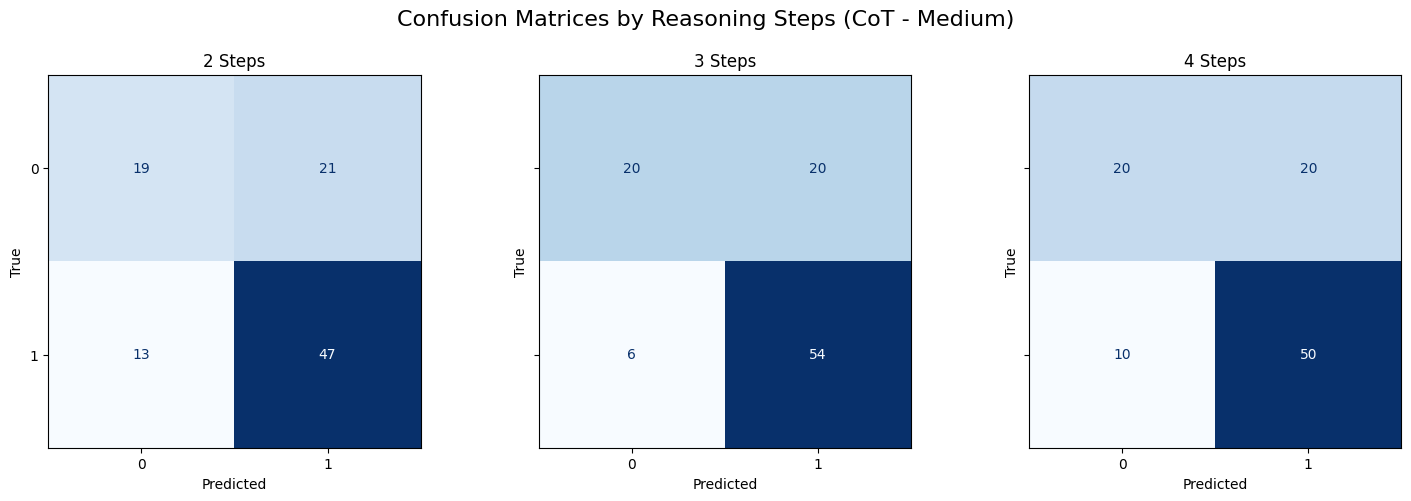


=== Accuracy Table ===

           accuracy  count
num_steps                 
2              0.66    100
3              0.74    100
4              0.70    100


In [16]:
import pandas as pd
import os
import re
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results_dir = "results/cot/medium"
records = []

for file in os.listdir(results_dir):
    if re.match(r"results_manipulation_cot_\dsteps\.csv", file):
        match = re.search(r"cot_(\d)steps", file)
        if match:
            num_steps = int(match.group(1))
            df = pd.read_csv(os.path.join(results_dir, file))
            df["num_steps"] = num_steps
            df["regime"] = "medium"
            records.append(df)

cot_results = pd.concat(records, ignore_index=True)


grouped = cot_results.groupby("num_steps")

for num_steps, group in grouped:
    print(f"\n=== Reasoning Steps: {num_steps} ===")
    y_true = group["true_label"].astype(int)
    y_pred = group["pred_label"].astype(int)
    print(classification_report(y_true, y_pred, digits=3))


def plot_confusion_matrix_sklearn(y_true, y_pred, title="Confusion Matrix", ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format='d')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for i, num_steps in enumerate(sorted(cot_results["num_steps"].unique())):
    ax = axes[i]
    subset = cot_results[cot_results["num_steps"] == num_steps]
    y_true = subset["true_label"].astype(int)
    y_pred = subset["pred_label"].astype(int)
    plot_confusion_matrix_sklearn(y_true, y_pred, title=f"{num_steps} Steps", ax=ax)

fig.suptitle("Confusion Matrices by Reasoning Steps (CoT - Medium)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


summary = (
    cot_results
    .assign(correct=lambda df: df["true_label"] == df["pred_label"])
    .groupby("num_steps")
    .agg(accuracy=("correct", "mean"), count=("correct", "size"))
    .reset_index()
)

print("\n=== Accuracy Table ===\n")
print(summary.set_index("num_steps").round(3))
